# Project 8: Forward Volatility from the SOFR Cap Market

**Data**: `project_cap_vol_ts.xlsx`, `cap_curves_2025-06-30.xlsx`, `ref_rates.xlsx`


## Project Statement

Strip forward volatilities from the SOFR cap market over 2022–2025 and test whether the forward vol curve predicts future spot vol—a Fama–Bliss analog for the volatility term structure. Characterize the resulting volatility term premium and analyze how it varies across the hiking, pause, and easing regimes of the Fed's policy cycle.


## Context

### From Flat Vol to Forward Vol

In the cap market, prices are quoted in **flat volatility**—a single implied vol that prices all caplets in a given cap, regardless of their individual maturities. This is a quoting convention, analogous to yield-to-maturity for bonds. Just as bond pricing requires spot rates (not YTM), derivative pricing requires **forward volatilities** that assign each caplet its own vol consistent with its maturity.

Extracting forward vols from flat vols is a **bootstrap** problem: given a sequence of cap prices at maturities $T_1 < T_2 < \ldots$, strip out the incremental caplet prices and invert Black's formula to recover the forward vol at each tenor. Exercise 7.1 walks through this on a single date.

### The Vol Curve as a Forecast

The forward vol curve has a natural interpretation as a forecast of future rate volatility. The $\tau$-year forward caplet vol represents the market's expectation (plus any risk premium) for rate volatility during the quarter ending at $\tau$.

A natural question, then, is whether forward vol is an unbiased predictor of future spot vol. This is the **Fama–Bliss analog for volatility**: just as forward rates predict future spot rates (but with a term premium), forward vols may predict future spot vols—but with a **volatility term premium**.

### Normal vs Black Vol

Bloomberg quotes cap vols in **normal** (Bachelier) terms, reported in basis points. For comparing forward vol across different rate levels and to realized rate volatility, normal vol is the appropriate measure:

$$\sigma_{\text{normal}} \approx \sigma_{\text{Black}} \times f$$

where $f$ is the forward rate. This approximation is exact at-the-money.

### The 2022–2025 Rate Cycle

This project covers a period of extraordinary rate volatility:

| Period | Regime | SOFR Range | Implication |
|--------|--------|------------|-------------|
| Mar 2022 – Jul 2023 | Aggressive hiking | 0.05% → 5.30% | High realized vol, uncertain terminal rate |
| Aug 2023 – Aug 2024 | Pause | ~5.30% | Low realized vol, high implied vol (when does the cut come?) |
| Sep 2024 – Dec 2025 | Easing | 5.30% → ~3.75% | Moderate realized vol, declining implied vol |

These three regimes create a natural laboratory for studying how the volatility term premium behaves under different policy conditions.


## Resources

### Course Materials

- **Discussion 7.1**: Forward Volatility and Caps — flat vs forward vol, stripping mechanics, Black's formula for caplets
- **Exercise 7.1**: Stripping Caps — single-date bootstrap of forward vols from flat vols (the starting point for Q1)
- **Discussion 5.1**: SOFR Swap Curve — discount factor construction needed for cap pricing

### External Reading

- CME Group: [Interest Rate Volatility](https://www.cmegroup.com/education/courses/introduction-to-interest-rate-options.html) — market structure for rate options
- NY Fed: [SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr) — rate calculation methodology
- Federal Reserve: [FOMC Calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm) — policy dates for regime classification

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `project_cap_vol_ts.xlsx` | Cap flat vols (normal, bp) + SOFR swap rates | Daily | 2022–2025 |
| `cap_curves_2025-06-30.xlsx` | Processed rate/vol curves for validation | Single date | 2025-06-30 |
| `ref_rates.xlsx` | Daily SOFR, Fed Funds, T-bill rates | Daily | 2018–2025 |

**Data location**: All files are in the `../data/` directory relative to this notebook.

#### Cap Vol Data Details

The `project_cap_vol_ts.xlsx` file contains two sheets:
- **`cap`**: ATM normal vol quotes for 1Y–10Y SOFR caps (Bloomberg `USCNSQ{1-10} SMKO Curncy`). Vols are in basis points.
- **`sofr`**: SOFR swap rates at monthly/quarterly/annual tenors up to 10Y. Rates are in percent, annually compounded.

The first row of each sheet contains maturity metadata (in years). Subsequent rows are daily observations.

### Additional Data Sources
- **FRED**: Daily SOFR rate for realized vol computation (already in `ref_rates.xlsx`)
- **Bloomberg** (optional): If you have access, you can pull additional cap maturities or OTM strikes via the `VCUB` screen


## Data Preview

The following code loads the data and creates initial visualizations.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('./data')

In [5]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

print(f'Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}')
print(f'Date range: {cap_data.index.min().date()} to {cap_data.index.max().date()}')
cap_data.tail(3)

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Date range: 2022-03-17 to 2025-12-31


maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2025-12-29,52.2,66.8,73.5,77.3,79.6,81.2,82.1,82.8,83.3,83.7
2025-12-30,50.9,66.1,72.9,76.7,78.9,80.4,81.3,81.9,82.4,82.8
2025-12-31,50.8,65.9,72.9,76.7,78.9,80.4,81.4,82.0,NaN,NaN


In [6]:
# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

print(f'SOFR swap data: {sofr_data.shape[0]} days, {sofr_data.shape[1]} tenors')
sofr_data.tail(3)

SOFR swap data: 1033 days, 21 tenors


maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2025-12-29,0.036670,0.035886,0.034989,0.034239,0.033538,0.033140,0.032940,...,0.033746,0.034104,0.034800,0.035506,0.036177,0.036827,0.037457
2025-12-30,0.036567,0.035805,0.034931,0.034190,0.033510,0.033115,0.032919,...,0.033849,0.034214,0.034927,0.035648,0.036330,0.036989,0.037621
2025-12-31,0.036517,0.035796,0.034961,0.034270,0.033631,0.033285,0.033140,...,0.034226,0.034638,0.035355,0.036068,0.036735,0.037388,0.038023


In [7]:
# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100
print(f'SOFR daily: {len(sofr_daily)} observations, {sofr_daily.index.min().date()} to {sofr_daily.index.max().date()}')

SOFR daily: 1935 observations, 2018-04-03 to 2025-12-31


In [8]:
# Load validation curves (single-date, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')

print(f'Validation curves: {curves_validation.shape}')
display(curves_validation.head())

Validation curves: (40, 6)


,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


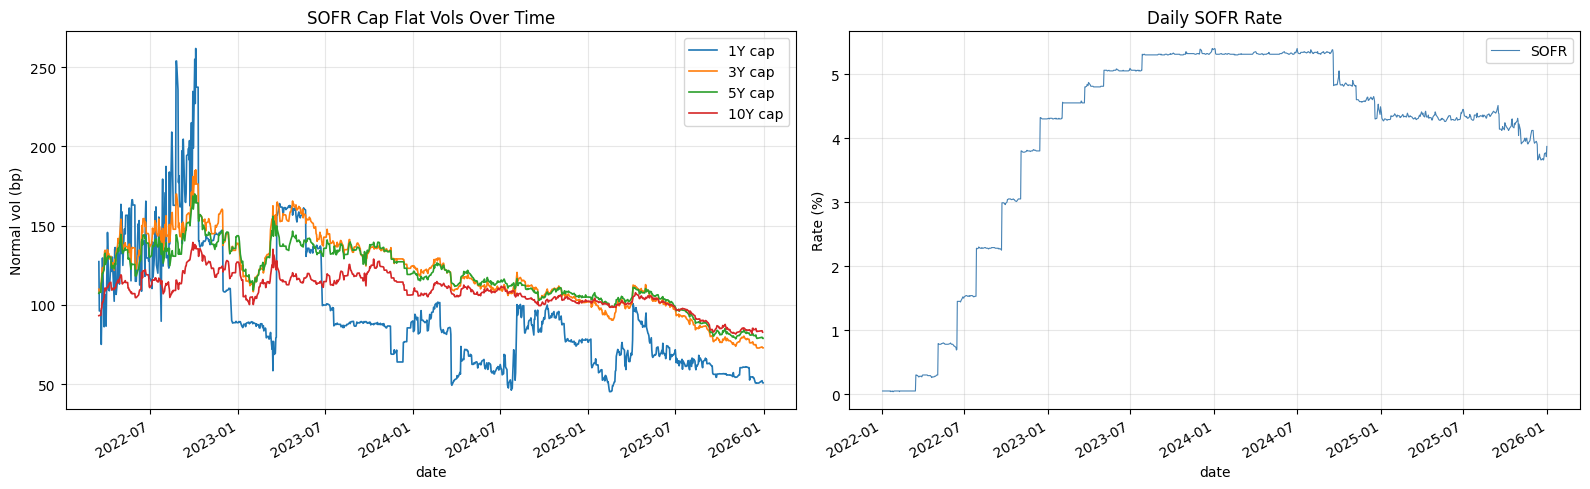

In [9]:
# Figure 1: Cap flat vols over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for mat in [1.0, 3.0, 5.0, 10.0]:
    if mat in cap_data.columns:
        cap_data[mat].dropna().plot(ax=ax, label=f'{int(mat)}Y cap', linewidth=1.2)
ax.set_ylabel('Normal vol (bp)')
ax.set_title('SOFR Cap Flat Vols Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# SOFR rate for context
ax = axes[1]
sofr_rate_pct = sofr_daily.loc['2022':] * 100
sofr_rate_pct.plot(ax=ax, linewidth=0.8, color='steelblue', label='SOFR')
ax.set_ylabel('Rate (%)')
ax.set_title('Daily SOFR Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

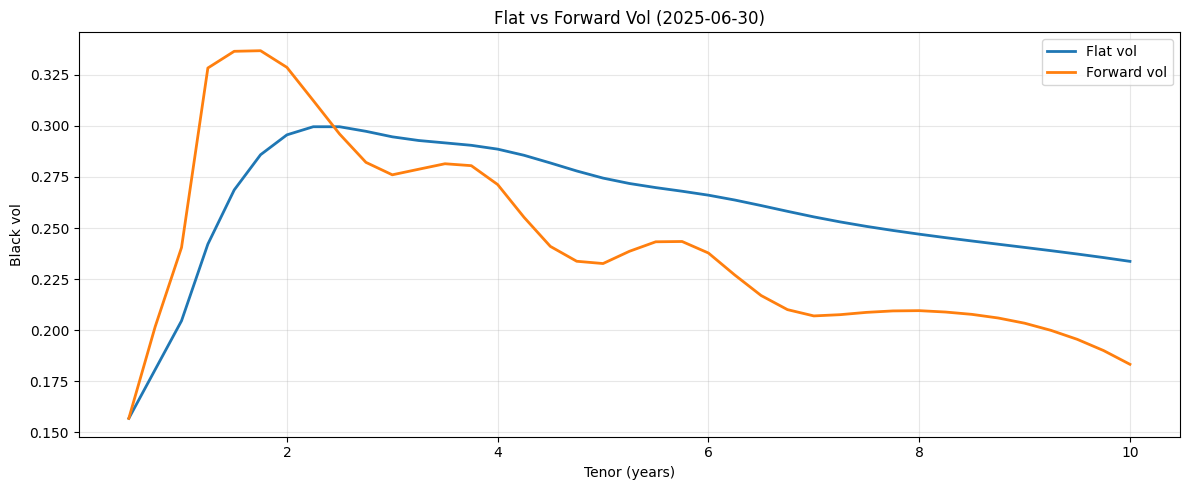

In [10]:
# Figure 2: Flat vs forward vol on the validation date
fig, ax = plt.subplots()
curves_validation['flat vols'].dropna().plot(ax=ax, label='Flat vol', linewidth=2)
curves_validation['fwd vols'].dropna().plot(ax=ax, label='Forward vol', linewidth=2)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Black vol')
ax.set_title('Flat vs Forward Vol (2025-06-30)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Formulas

Refer to **Discussion 7.1** and **Exercise 7.1** for detailed derivations.

### Black's Formula for a Caplet

$$P_{\text{caplet}} = \frac{100}{4} \cdot Z_\tau \left[ f_\tau \mathcal{N}(d_1) - K \mathcal{N}(d_2) \right]$$

where $d_1 = \frac{\ln(f_\tau/K) + \frac{\sigma^2}{2}(\tau - 0.25)}{\sigma\sqrt{\tau - 0.25}}$ and $d_2 = d_1 - \sigma\sqrt{\tau - 0.25}$.

### Cap Price from Flat Vol

A cap with maturity $T$ and flat vol $\sigma_{\text{flat},T}$:

$$P_{\text{cap}}(T) = \sum_{\tau=0.5}^{T} P_{\text{caplet}}(\tau, \sigma_{\text{flat},T}, K=s_T)$$

where $s_T$ is the ATM swap rate.

### Forward Vol Bootstrap

The caplet price at $\tau$ is:
$$P_{\text{caplet}}(\tau) = P_{\text{cap}}(\tau) - P_{\text{cap}}(\tau - 0.25)$$

Invert Black's formula to find $\sigma_{\text{fwd},\tau}$.

### Normal Vol Conversion (ATM)

$$\sigma_{\text{normal}} = \sigma_{\text{Black}} \times f$$

### Fama–Bliss Analog for Volatility

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

where $h = \tau - \delta$ is the forecast horizon and $\delta$ is the spot caplet tenor.

### Volatility Term Premium

$$\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$$

### Realized Vol

$$\sigma_{\text{realized}, t \to t+k} = \text{std}(\Delta r_{\text{SOFR}}) \times \sqrt{252}$$

computed over daily SOFR rate changes in the window $[t, t+k]$.


## Questions

Address the following questions in your analysis.


In [49]:
def normal_vol_to_black_vol(date, cap_data, sofr_data):
    """
    Select a single date from the time series
    Use that dates cap flat cols and SOFR swap rates
    convert bloomberg normal vols to black vols
    """
    cap_slice = cap_data.loc[date].dropna()
    sofr_slice = sofr_data.loc[date].dropna()

    cap_slice_bloomberg = cap_slice / 10000
    fwd_rates = sofr_slice.reindex(cap_slice_bloomberg.index).interpolate()
    black_vol = cap_slice_bloomberg / fwd_rates

    black_vol.name = "black_vol"

    display(pd.DataFrame({
        "normal_vol(bp)": cap_slice,
        "swap_rate": fwd_rates,
        "black_vol": black_vol
    }))
    return cap_slice, sofr_slice, black_vol

In [50]:
def get_market_slices(date, cap_data, sofr_data):
    """
    Extract one-date cap and swap slices.
    """
    cap_slice = cap_data.loc[date].dropna().astype(float)
    swap_slice = sofr_data.loc[date].dropna().astype(float)
    return cap_slice, swap_slice

In [52]:
def build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid):
    """
    Convert annual cap normal vols (bp) to Black flat vols,
    then interpolate to the quarterly tenor grid.
    """
    normal_vol = cap_slice / 10000.0

    approx_atm_rates = (
        swap_slice.reindex(normal_vol.index)
        .interpolate(method="linear", limit_direction="both")
    )

    black_vol = normal_vol / approx_atm_rates

    flat_vols = (
        black_vol.reindex(quarterly_grid)
        .interpolate(method="linear", limit_direction="both")
    )

    flat_vols.loc[0.25] = np.nan
    flat_vols.name = "flat vols"
    return flat_vols

In [53]:
def build_quarterly_swap_curve(swap_slice, quarterly_grid):
    """
    Interpolate swap rates onto the quarterly tenor grid.
    """
    swap_q = (
        swap_slice.reindex(quarterly_grid)
        .interpolate(method="linear", limit_direction="both")
    )
    swap_q.name = "swap rates"
    return swap_q

In [55]:
def bootstrap_discount_forward_curve(swap_q, delta):
    """
    Vanilla par-swap bootstrap:
      swap rates -> discounts -> spot rates -> forward rates
    """
    tenor_grid = np.array(swap_q.index, dtype=float)

    discounts = pd.Series(index=swap_q.index, dtype=float)

    for j, T in enumerate(tenor_grid, start=1):
        S = swap_q.loc[T]

        if j == 1:
            discounts.loc[T] = 1 / (1 + S * delta)
        else:
            prev_times = tenor_grid[:j-1]
            discounts.loc[T] = (1 - S * delta * discounts.loc[prev_times].sum()) / (1 + S * delta)

    discounts.name = "discounts"

    spot_rates = pd.Series(index=swap_q.index, dtype=float)
    for T in tenor_grid:
        spot_rates.loc[T] = discounts.loc[T] ** (-1 / T) - 1
    spot_rates.name = "spot rates"

    forwards = pd.Series(index=swap_q.index, dtype=float)
    forwards.loc[tenor_grid[0]] = np.nan

    for j in range(1, len(tenor_grid)):
        T_prev = tenor_grid[j-1]
        T = tenor_grid[j]
        forwards.loc[T] = (discounts.loc[T_prev] / discounts.loc[T] - 1) / delta

    forwards.name = "forwards"

    return discounts, spot_rates, forwards

In [62]:
# Bootstrap forward vols from flat vols using the caplet stripping method
def black_caplet_price(F, K, sigma, tau, DF, delta, notional):

    if pd.isna(F) or pd.isna(K) or pd.isna(sigma) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    if sigma <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    vol_sqrt_t = sigma * np.sqrt(option_expiry)
    if vol_sqrt_t <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * option_expiry) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    return notional * delta * DF * (F * norm.cdf(d1) - K * norm.cdf(d2))

def implied_black_caplet_vol(price, F, K, tau, DF, delta, notional):
    
    if pd.isna(price) or pd.isna(F) or pd.isna(K) or pd.isna(tau) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    intrinsic = notional * delta * DF * max(F - K, 0.0)

    # tiny numerical tolerance around intrinsic
    if price <= intrinsic + 1e-12:
        return 0.0

    def objective(sigma):
        return black_caplet_price(F, K, sigma, tau, DF, delta=delta, notional=notional) - price

    try:
        return brentq(objective, 1e-8, 5.0)
    except ValueError:
        return np.nan



In [69]:
def price_caps_from_flat_vols(flat_vols, swap_q, discounts, forwards, delta, notional):
    """
    Price each T-maturity cap using:
      - flat vol sigma_flat(T)
      - ATM strike K = swap rate at T
      - sum of Black caplets up to T
    """
    tenor_grid = np.array(flat_vols.index, dtype=float)
    cap_prices = pd.Series(index=flat_vols.index, dtype=float)

    for T in tenor_grid:
        sigma_flat = flat_vols.loc[T]

        if T < 0.50 or pd.isna(sigma_flat):
            cap_prices.loc[T] = np.nan
            continue

        K = swap_q.loc[T]
        cap_val = 0.0

        caplet_payment_dates = tenor_grid[(tenor_grid >= 0.50) & (tenor_grid <= T)]

        for tau in caplet_payment_dates:
            F = forwards.loc[tau]
            DF = discounts.loc[tau]
            cap_val += black_caplet_price(F=F, K=K, sigma=sigma_flat, tau=tau, DF=DF, delta=delta, notional=notional)

        cap_prices.loc[T] = cap_val

    cap_prices.name = "cap prices"
    return cap_prices

In [59]:
def strip_caplet_prices(cap_prices, delta):
    """
    Strip caplet prices from adjacent cap prices:
      caplet(T) = cap(T) - cap(T-delta)
    """
    tenor_grid = np.array(cap_prices.index, dtype=float)
    caplet_prices = pd.Series(index=cap_prices.index, dtype=float)

    for T in tenor_grid:
        if T < 0.50 or pd.isna(cap_prices.loc[T]):
            caplet_prices.loc[T] = np.nan
        elif np.isclose(T, 0.50):
            caplet_prices.loc[T] = cap_prices.loc[T]
        else:
            prev_T = round(T - delta, 10)
            caplet_prices.loc[T] = cap_prices.loc[T] - cap_prices.loc[prev_T]

    caplet_prices.name = "caplet prices"
    return caplet_prices

In [77]:
def invert_caplet_prices_to_fwd_vols(caplet_prices, swap_q, discounts, forwards, delta):
    """
    Convert stripped caplet prices to Black forward caplet vols.
    """
    tenor_grid = np.array(caplet_prices.index, dtype=float)
    fwd_vols = pd.Series(index=caplet_prices.index, dtype=float)

    for tau in tenor_grid:
        if tau < 0.50 or pd.isna(caplet_prices.loc[tau]):
            fwd_vols.loc[tau] = np.nan
            continue

        F = forwards.loc[tau]
        DF = discounts.loc[tau]
        K = swap_q.loc[tau]
        price = caplet_prices.loc[tau]

        fwd_vols.loc[tau] = implied_black_caplet_vol(price=price, F=F, K=K, tau=tau, DF=DF, delta=delta, notional=notional)

    fwd_vols.name = "fwd vols"
    return fwd_vols

In [82]:
def strip_forward_vol_curve(date, cap_data, sofr_data, quarterly_grid, delta, notional):
    """
    Full one-date pipeline:
      market slices
      -> flat vols
      -> quarterly swap curve
      -> discounts/spots/forwards
      -> cap prices
      -> caplet prices
      -> forward vols
    """
    cap_slice, swap_slice = get_market_slices(date, cap_data, sofr_data)

    flat_vols = build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid=quarterly_grid)
    swap_q = build_quarterly_swap_curve(swap_slice, quarterly_grid=quarterly_grid)

    discounts, spot_rates, forwards = bootstrap_discount_forward_curve(swap_q, delta=delta)

    cap_prices = price_caps_from_flat_vols(
        flat_vols=flat_vols,
        swap_q=swap_q,
        discounts=discounts,
        forwards=forwards,
        delta=delta,
        notional=notional
    )

    caplet_prices = strip_caplet_prices(cap_prices, delta=delta)

    fwd_vols = invert_caplet_prices_to_fwd_vols(
        caplet_prices=caplet_prices,
        swap_q=swap_q,
        discounts=discounts,
        forwards=forwards,
        delta=delta
    )

    curve = pd.DataFrame({
        "swap rates": swap_q,
        "spot rates": spot_rates,
        "discounts": discounts,
        "forwards": forwards,
        "flat vols": flat_vols,
        "cap prices": cap_prices,
        "caplet prices": caplet_prices,
        "fwd vols": fwd_vols
    })

    return curve

In [65]:
delta = 0.25
notional = 100
quarterly_grid = np.arange(0.25, 10.25, 0.25)
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]

### Question 1: Cap Stripping Mechanics

**Replicate and extend E.7.1 using the provided time-series data.**

a) Select a single date from the time series. Using that date's cap flat vols and SOFR swap curve, build the full processing pipeline:
   - Convert Bloomberg normal vols (bp) to Black vols
   - Interpolate to a quarterly grid
   - Construct discount and forward curves
   - Bootstrap forward vols from flat vols

   Validate your pipeline against the processed `cap_curves_2025-06-30.xlsx` file.

In [83]:
Q1a_date = pd.Timestamp("2025-06-30")
curve_q1 = strip_forward_vol_curve(Q1a_date, cap_data, sofr_data, quarterly_grid = quarterly_grid, delta = delta, notional = notional)
display(curve_q1.head(12))

,swap rates,spot rates,discounts,forwards,flat vols,cap prices,caplet prices,fwd vols
maturity,,,,,,,,
0.25,0.043019,0.043718,0.989360,NaN,NaN,NaN,NaN,NaN
0.50,0.041467,0.042107,0.979589,0.039899,0.181032,0.019975,0.019975,0.181032
0.75,0.039991,0.040574,0.970611,0.036997,0.181032,0.054069,0.034094,0.243169
1.00,0.038667,0.039197,0.962282,0.034625,0.181032,0.100740,0.046671,0.285872
1.25,0.037205,0.037672,0.954827,0.031229,0.201241,0.179509,0.078769,0.429612
1.50,0.036121,0.036544,0.947586,0.030565,0.221450,0.274193,0.094684,0.435217
1.75,0.035409,0.035804,0.940296,0.031013,0.241660,0.386083,0.111890,0.419978
2.00,0.034903,0.035279,0.933008,0.031246,0.261869,0.518827,0.132744,0.428661
2.25,0.034435,0.034792,0.925935,0.030555,0.267887,0.639023,0.120196,0.384830


In [97]:
# Validte against provided curves
q1_compare = curve_q1[["swap rates", "spot rates", "discounts", "forwards", "flat vols", "fwd vols"]].copy()
q1_compare.index.name = "tenor"

common_index = q1_compare.index.intersection(curves_validation.index)
common_cols = q1_compare.columns.intersection(curves_validation.columns)

validation_compare = curves_validation.loc[common_index, common_cols].copy()
model_compare = q1_compare.loc[common_index, common_cols].copy()

# Absolute difference
abs_diff = model_compare - validation_compare

# Relative difference
rel_diff = abs_diff / validation_compare

validation_summary = pd.DataFrame({
    "mean_abs_error": abs_diff.abs().mean(),
    "max_abs_error": abs_diff.abs().max(),
    "rmse": np.sqrt((abs_diff**2).mean()),
    "mean_rel_error": rel_diff.abs().mean(),
    "max_rel_error": rel_diff.abs().max()
}).sort_index()

display(validation_summary)

,mean_abs_error,max_abs_error,rmse,mean_rel_error,max_rel_error
discounts,0.001864,0.003501,0.002104,0.002364,0.005042
flat vols,0.022643,0.047192,0.025549,0.089585,0.175669
forwards,0.000506,0.000670,0.000518,0.013718,0.015995
fwd vols,0.026221,0.101271,0.040158,0.095129,0.308433
spot rates,0.000954,0.001365,0.000961,0.026962,0.032224
swap rates,0.000469,0.000666,0.000472,0.013270,0.015721


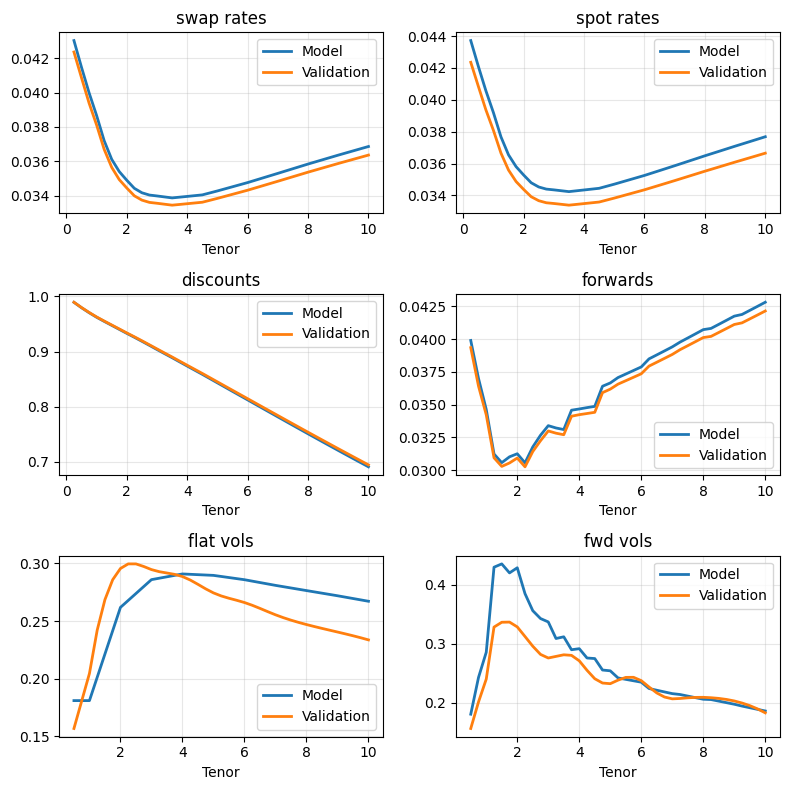

In [96]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, col in zip(axes, common_cols):
    model_compare[col].dropna().plot(ax=ax, linewidth=2, label="Model")
    validation_compare[col].dropna().plot(ax=ax, linewidth=2, label="Validation")
    ax.set_title(col)
    ax.set_xlabel("Tenor")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically **humped**: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

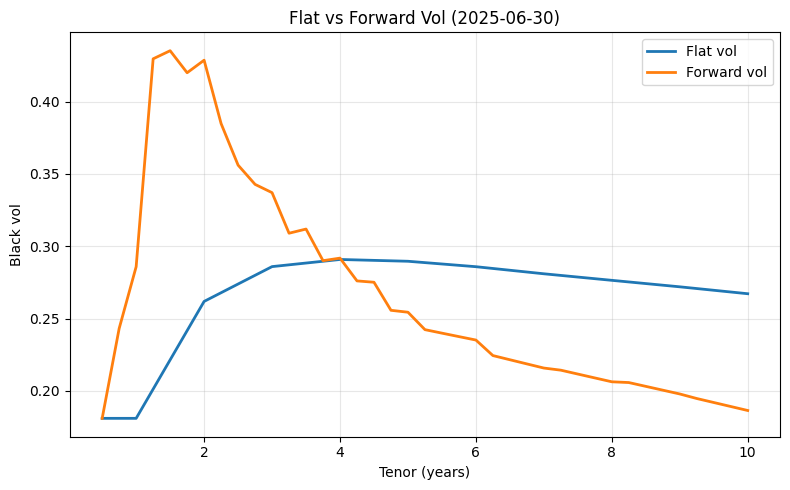

In [85]:
fig, ax = plt.subplots(figsize=(8, 5))

curve_q1["flat vols"].dropna().plot(ax=ax, linewidth=2, label="Flat vol")
curve_q1["fwd vols"].dropna().plot(ax=ax, linewidth=2, label="Forward vol")

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black vol")
ax.set_title(f"Flat vs Forward Vol ({Q1a_date.date()})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?

### Question 2: Forward Vol Time Series

**Build a panel of forward vols by stripping the cap curve on each date in the time series.**

a) Process each weekly date in the sample (resample the daily data to weekly frequency). For each date, extract forward caplet vols at key tenors: 0.5Y, 1Y, 2Y, 3Y, 5Y. Store these in a panel indexed by date and tenor.

In [42]:
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]

b) Plot the forward vol time series at each tenor. Describe the dynamics:
   - Which tenors are most volatile?
   - How did forward vol evolve through the hiking cycle (2022–23), the pause (2023–24), and the easing (2024–25)?

c) Report summary statistics (mean, std, min, max) for the forward vol panel. Be sure to discuss whether you are working in Black or normal vol units and why that choice matters for cross-tenor comparisons.

### Question 3: Predictive Power of the Forward Vol Curve

**Test whether today's forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.**

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting $R^2$.*

a) Define the "spot" caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).

b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

### Question 4: The Volatility Term Premium

**Characterize the volatility term premium implied by the forward vol curve and assess its reliability across tenors.**

a) Define the **volatility term premium**: $\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$. Plot this over time and report what fraction of observations are positive. Does the VTP grow with tenor?

b) For each forward horizon in your panel ($\tau$ = 1Y, 1.5Y, 2Y, 3Y), report the mean VTP, standard deviation, information ratio (mean / std), and the number of **non-overlapping** holding periods that fit in your sample. Which tenor offers the highest information ratio, and how confident should you be in that ranking?

c) Split your sample in half (e.g., pre- and post-2024). Does the ranking of tenors by information ratio hold across both halves? Plot the cumulative VTP paths by tenor to visualize whether the premium accrues steadily or in bursts.

### Question 5: Implied vs. Realized Vol and Carry Strategy

**Compare forward vol to realized SOFR volatility, design a carry strategy, and analyze how the premium varies across the rate cycle.**

a) Compute realized SOFR vol: for each date, calculate the annualized standard deviation of daily SOFR rate changes over the subsequent 3 or 6 months. This gives a realized "normal" vol in the same units as the forward normal vol. Define the **vol risk premium**: $\text{VRP}_t = \sigma_{\text{fwd},t}^{(\tau)} - \sigma_{\text{realized}, t \to t+k}$. Plot the VRP over time and compare it to the VTP from Q4.

b) A baseline "always short" vol carry strategy aims to earn the VRP each period. Compute its cumulative P&L (in vol units) and hit rate. Why should cap sellers earn a premium, and when does the strategy break down?

c) Classify the sample into three regimes: **Hiking** (March 2022 – July 2023), **Pause** (August 2023 – August 2024), and **Easing** (September 2024 – December 2025). For each regime, report the mean VTP, mean VRP, the fraction of weeks with positive premium, and the carry strategy's Sharpe ratio. Visualize the premium distributions across regimes. Interpret the variation.

### Question 6: Harvesting the Vol Premium in Practice

**Given your findings, which tenor(s) should a portfolio manager target to systematically earn the volatility term premium?**

a) Consider transaction costs. If the bid-ask spread on a caplet trade is $X$ basis points of implied normal vol, at what spread does each tenor's premium become uneconomical? Compute the breakeven bid-ask spread for each tenor. Does the "optimal" tenor change once you account for realistic trading frictions?

   *Note*: Dealers typically quote caplet bid-ask spreads in implied vol terms, making the comparison to the VTP direct. If instead costs are quoted in price terms (bp of notional), converting to vol space requires dividing by the caplet's vega—the sensitivity of price to a 1 bp change in implied vol.

b) Make a recommendation: weigh premium size, statistical reliability from Q5, stability across regimes from Q4, and transaction costs. Is there a single best tenor, or does the answer depend on assumptions? What would you monitor to update this recommendation going forward?

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all six questions (Q1–Q6), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: Is the forward vol curve an unbiased predictor of future spot vol? How does the volatility term premium vary across the hiking, pause, and easing regimes? Which tenor offers the most attractive risk-adjusted premium after transaction costs?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).